## Required Libararies
Importing the required libraries for our model


In [1]:
%pip install -q kagglehub scipy joblib

import kagglehub
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.io import loadmat
import h5py
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Environment Ready.")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\VICTUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Environment Ready.


## Download and extract the Data
This fetches the dataset and identifies the paths for the pre-processed segmented files


In [3]:
path = kagglehub.dataset_download("cinthyazuniga/ds2-emg-signals-three-force-type")

# Define the file paths for the segmented data
emg_s_path = os.path.join(path, "EMG_WS_all.mat")
labels_path = os.path.join(path, "Window_label_gestures.mat")

print(f"Data located at: {path}")

Resuming download from 36700160 bytes (1086804843 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/cinthyazuniga/ds2-emg-signals-three-force-type?dataset_version_number=8 (36700160/1123505003) bytes left.


100%|██████████| 1.05G/1.05G [18:46<00:00, 964kB/s] 

Extracting files...


Data located at: C:\Users\VICTUS\.cache\kagglehub\datasets\cinthyazuniga\ds2-emg-signals-three-force-type\versions\8


## Loading and Extracting Data Features
EMG_WS_all.mat contains 332108 windows of 375 samples across 3 channels.

We will calculate the important features (Mean Absolute Value, Root Mean Square, Waveform Length, Zero Crossing, Slope Sign Change) of each 375ms window per channel. This turns 375 numbers into 5 features per channel, giving us a small input vector of 15 (5 * 3) features instead of 1125 values (375 * 3)

In [4]:
# Setup the File Reference (Doesn't load into RAM yet)
f_emg = h5py.File(emg_s_path, 'r')
raw_data_ref = f_emg['final_matrix'] # This is just a pointer

# We need to know the total number of windows
num_windows = raw_data_ref.shape[2]
num_features = 15 # (MAV, WL, RMS, ZC, SSC) * 3 channels

# Pre-allocate the Feature Matrix (Much smaller than raw data)
X = np.zeros((num_windows, num_features), dtype=np.float32)

# Define the Chunking Logic
chunk_size = 10000 # Process 10k windows at a time, avoid rams crashing due to large number of windows (300K)
print(f"Processing {num_windows} windows in chunks of {chunk_size}...")

def extract_features_single_chunk(data):
    # data shape here is (Windows, Channels, Samples)
    mav = np.mean(np.abs(data), axis=2)
    wl = np.sum(np.abs(np.diff(data, axis=2)), axis=2)
    rms = np.sqrt(np.mean(data**2, axis=2))

    threshold = 0.01
    zc = np.sum((data[:, :, :-1] * data[:, :, 1:] < 0) &
                (np.abs(data[:, :, :-1] - data[:, :, 1:]) > threshold), axis=2)

    diff = np.diff(data, axis=2)
    ssc = np.sum((diff[:, :, :-1] * diff[:, :, 1:] < 0) &
                 (np.abs(diff[:, :, :-1] - diff[:, :, 1:]) > threshold), axis=2)

    return np.hstack([mav, wl, rms, zc, ssc])

# The Processing Loop
for i in range(0, num_windows, chunk_size):
    end = min(i + chunk_size, num_windows)

    # Pull only a small slice from the disk into RAM
    # We transpose from (200, 3, Chunk) to (Chunk, 3, 200)
    chunk_raw = np.array(raw_data_ref[:, :, i:end]).transpose(2, 1, 0)

    # Extract features and store in our pre-allocated matrix
    X[i:end, :] = extract_features_single_chunk(chunk_raw)

    if i % 20000 == 0:
        print(f"Progress: {i}/{num_windows} windows processed.")

f_emg.close()
print("Feature extraction complete!")

Processing 332108 windows in chunks of 10000...
Progress: 0/332108 windows processed.
Progress: 20000/332108 windows processed.
Progress: 40000/332108 windows processed.
Progress: 60000/332108 windows processed.
Progress: 80000/332108 windows processed.
Progress: 100000/332108 windows processed.
Progress: 120000/332108 windows processed.
Progress: 140000/332108 windows processed.
Progress: 160000/332108 windows processed.
Progress: 180000/332108 windows processed.
Progress: 200000/332108 windows processed.
Progress: 220000/332108 windows processed.
Progress: 240000/332108 windows processed.
Progress: 260000/332108 windows processed.
Progress: 280000/332108 windows processed.
Progress: 300000/332108 windows processed.
Progress: 320000/332108 windows processed.
Feature extraction complete!


In [5]:
# Load Labels (Hybrid Scipy/H5PY)
try:
    with h5py.File(labels_path, 'r') as f_lab:
        possible_keys = [k for k in f_lab.keys() if not k.startswith('#')]
        labels_data = np.array(f_lab[possible_keys[0]])
except OSError:
    mat_contents = sio.loadmat(labels_path)
    data_key = [k for k in mat_contents.keys() if not k.startswith('__')][0]
    labels_data = mat_contents[data_key]

# If labels are (5, sample size), transpose to (sample size, 5)
if labels_data.shape[0] == 5:
    labels_data = labels_data.T

# Convert labels to single integers (0-4)
# If labels_data is one-hot (multiple columns), use argmax, if it's already a single column, just flatten it
if labels_data.ndim > 1 and labels_data.shape[1] > 1:
    y = np.argmax(labels_data, axis=1) # if labels are [0, 0, 1, 0, 0] returns 2 which the classifier expects
else:
    y = labels_data.flatten()

# Final Shape Verification
print("\n" + "=" *30)
print("FINAL DATASET SUMMARY")
print("="*30)
print(f"Feature Matrix (X) Shape: {X.shape} -> (Total Windows, Total Features)")
print(f"Label Vector (y) Shape:   {y.shape} -> (Total Windows,)")

# Check if they match
if X.shape[0] == y.shape[0]:
    print("\n✅ SUCCESS: X and y row counts match!")
else:
    print(f"\n❌ ERROR: Mismatch! X has {X.shape[0]} rows but y has {y.shape[0]} rows.")

print(f"Number of Channels used:  3")
print(f"Features per Channel:     5 (MAV, WL, RMS, ZC, SSC)")
print(f"Total input features:     {X.shape[1]}")
print("="*30)


FINAL DATASET SUMMARY
Feature Matrix (X) Shape: (332108, 15) -> (Total Windows, Total Features)
Label Vector (y) Shape:   (332108,) -> (Total Windows,)

✅ SUCCESS: X and y row counts match!
Number of Channels used:  3
Features per Channel:     5 (MAV, WL, RMS, ZC, SSC)
Total input features:     15


## Preprocessing and Scaling
We split the data and scale it. We save the scaler values specifically to be used in Arduino C++ code later

In [6]:
# 80% Training Dataset, 20% For Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # Centers around 0 with standard deviation of 1, ensuring all features contribute equally
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for later use
joblib.dump(scaler, 'scaler.gz')

print(f"float scaler_mean[] = {{ {', '.join(map(str, scaler.mean_))} }};")
print(f"float scaler_std[] = {{ {', '.join(map(str, scaler.scale_))} }};")

float scaler_mean[] = { 0.05661012993208668, 0.09641448713834118, 0.07488685315724168, 16.146311596299, 24.20092910282797, 19.988915643587706, 0.07299279317926267, 0.12500730288467626, 0.09832095662987281, 97.92357519778987, 72.55431976092079, 101.17435619490676, 174.77652190932153, 165.26716123544335, 180.10566608703508 };
float scaler_std[] = { 0.06671041317125753, 0.09636164674156267, 0.10294686580203045, 15.335629195316358, 23.96861410409583, 22.111393901041513, 0.08422804347526544, 0.12751304543181904, 0.13431826688505813, 27.823673483806353, 26.60559546539672, 26.526540513686587, 28.420299454128983, 32.025635349797206, 32.77913808548525 };


## Train the Lightweight Model


In [7]:
# Initialize the Neural Network Classifier Model
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,     # Initial learning rate (tf.keras.optimizers.Adam)
    early_stopping=True,          # Enables early stopping logic to prevent overfitting
    validation_fraction=0.2,
    n_iter_no_change=10,
    learning_rate='adaptive',     # Automatically lowers LR if loss plateaus
    batch_size=64,
    max_iter=200,
    verbose=True,                 # Shows progress per epoch
    random_state=42
)

# Train the Model
print("Starting training...")
model.fit(X_train_scaled, y_train)

# Quick Evaluation
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)
print(f"\nTraining Complete!\nTrain Accuracy: {train_acc*100:.2f}%\nTest Accuracy: {test_acc*100:.2f}%")


Starting training...
Iteration 1, loss = 0.89607684
Validation score: 0.690316
Iteration 2, loss = 0.74158004
Validation score: 0.727803
Iteration 3, loss = 0.68975221
Validation score: 0.743442
Iteration 4, loss = 0.65687410
Validation score: 0.756370
Iteration 5, loss = 0.63172440
Validation score: 0.765140
Iteration 6, loss = 0.61259232
Validation score: 0.770390
Iteration 7, loss = 0.59697527
Validation score: 0.780967
Iteration 8, loss = 0.58430845
Validation score: 0.783639
Iteration 9, loss = 0.57289075
Validation score: 0.792804
Iteration 10, loss = 0.56242256
Validation score: 0.788588
Iteration 11, loss = 0.55413975
Validation score: 0.797791
Iteration 12, loss = 0.54667358
Validation score: 0.798487
Iteration 13, loss = 0.53794990
Validation score: 0.801912
Iteration 14, loss = 0.53265677
Validation score: 0.807746
Iteration 15, loss = 0.52568378
Validation score: 0.804076
Iteration 16, loss = 0.51950631
Validation score: 0.812695
Iteration 17, loss = 0.51514502
Validation s

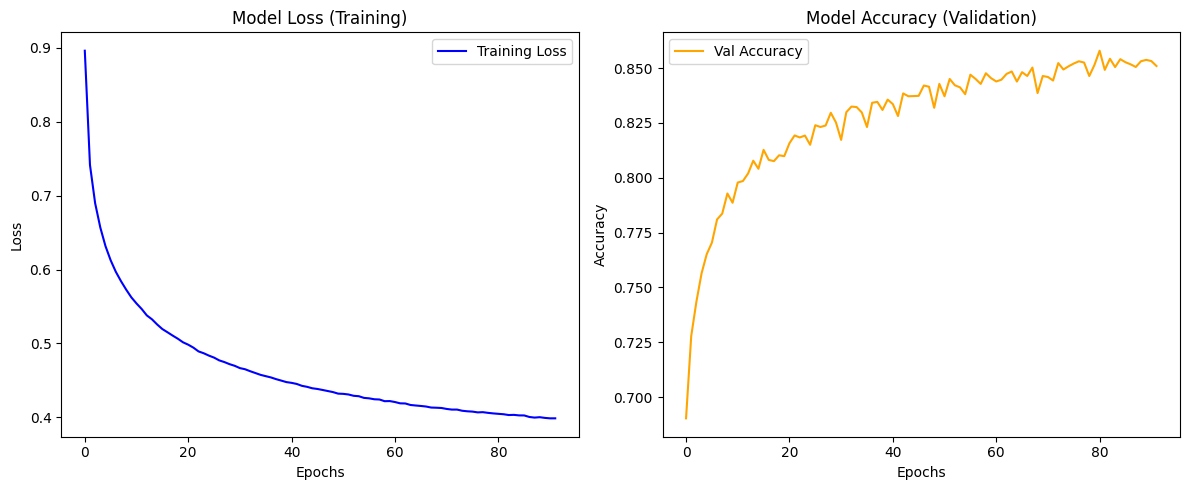

In [8]:
# Create the figure
plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(model.loss_curve_, label='Training Loss', color='blue')
plt.title('Model Loss (Training)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Validation Accuracy
plt.subplot(1, 2, 2)
if hasattr(model, 'validation_scores_'):
    plt.plot(model.validation_scores_, label='Val Accuracy', color='orange')
    plt.title('Model Accuracy (Validation)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

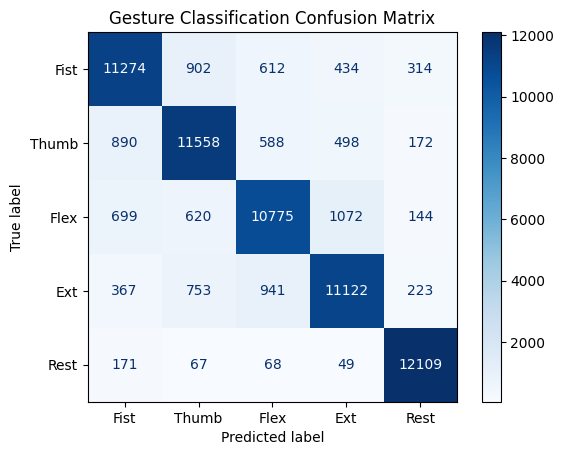

In [9]:
# Get predictions
y_pred = model.predict(X_test_scaled)

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot results
plt.figure(figsize=(8, 6))
labels = ["Fist", "Thumb", "Flex", "Ext", "Rest"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Gesture Classification Confusion Matrix')
plt.show()

### Training a Patient-Specific Intensity Regressor
Instead of just classifying the gesture, we will train the model to output a continuous value between 0 and 1 that represents the intensity relative to the peak recorded for that specific patient

In [10]:
# Dataset consists of 20 subjects
num_subjects = 20
windows_per_subject = len(X) // num_subjects

# We'll use the already calculated RMS features (indices 6, 7, 8 in X)
rms_vals = X[:, 6:9]
fused_rms = np.mean(rms_vals, axis=1) # Average RMS value across all 3 channels
y_intensity = np.zeros(len(X))

for s in range(num_subjects):
    start = s * windows_per_subject
    end = (s + 1) * windows_per_subject if s < num_subjects - 1 else len(X)

    subject_rms = fused_rms[start:end]

    # We need to identify 'High' force windows to set the 1.0 reference
    # The last third of a subject's data sequence corresponds to High Force
    one_third = len(subject_rms) // 3
    high_force_segment = subject_rms[2*one_third:]

    # Subject-specific reference using 95th percentile to avoid outliers
    subject_high_peak = np.percentile(high_force_segment, 95)

    # Normalize ALL windows for this subject by their specific peak
    y_intensity[start:end] = np.clip(subject_rms / subject_high_peak, 0.0, 1.0)

# Re-split for training using the 20-subject targets
indices = np.arange(len(X))
tr_idx, te_idx = train_test_split(indices, test_size=0.2, random_state=42)

y_train_i = y_intensity[tr_idx]
y_test_i = y_intensity[te_idx]

# Train Intensity Regressor, needed as muscle force is non linear, so simple regression would fail to capture complex relationships
intensity_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=50,
    verbose=True,
    random_state=42
)

print("Training Intensity Regressor on High-Force Normalized targets...")
intensity_model.fit(X_train_scaled, y_train_i)

# Evaluation
predictions = intensity_model.predict(X_test_scaled)
print(f"MAE: {np.mean(np.abs(predictions - y_test_i)):.4f}")

Training Intensity Regressor on High-Force Normalized targets...
Iteration 1, loss = 0.01032220
Iteration 2, loss = 0.00751953
Iteration 3, loss = 0.00671756
Iteration 4, loss = 0.00629456
Iteration 5, loss = 0.00619669
Iteration 6, loss = 0.00580646
Iteration 7, loss = 0.00569296
Iteration 8, loss = 0.00562303
Iteration 9, loss = 0.00536206
Iteration 10, loss = 0.00528619
Iteration 11, loss = 0.00512997
Iteration 12, loss = 0.00502687
Iteration 13, loss = 0.00502376
Iteration 14, loss = 0.00493125
Iteration 15, loss = 0.00479017
Iteration 16, loss = 0.00477159
Iteration 17, loss = 0.00471848
Iteration 18, loss = 0.00465079
Iteration 19, loss = 0.00461478
Iteration 20, loss = 0.00456114
Iteration 21, loss = 0.00457372
Iteration 22, loss = 0.00448958
Iteration 23, loss = 0.00445104
Iteration 24, loss = 0.00441706
Iteration 25, loss = 0.00441883
Iteration 26, loss = 0.00434308
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
MAE: 0.0632


In [ ]:
# Force the model predictions into a strict 0.0 to 1.0 range
predictions = np.clip(intensity_model.predict(X_test_scaled), 0.0, 1.0)

# Sample check: Showing how the model translates raw EMG into a force level
print(f"{'True Target':>15} | {'Model Pred':>10} ")
print("-" * 45)
for i in range(10):
    t = y_test_i[i]
    p = predictions[i]
    print(f"{t:15.4f} | {p:10.4f} ")

    True Target | Model Pred 
---------------------------------------------
         0.4097 |     0.3677 
         0.0582 |     0.0355 
         0.0578 |     0.0401 
         0.5352 |     0.5942 
         0.7002 |     0.3963 
         0.1303 |     0.1087 
         0.5917 |     0.5961 
         0.5403 |     0.6768 
         0.2236 |     0.2502 
         0.1510 |     0.1346 


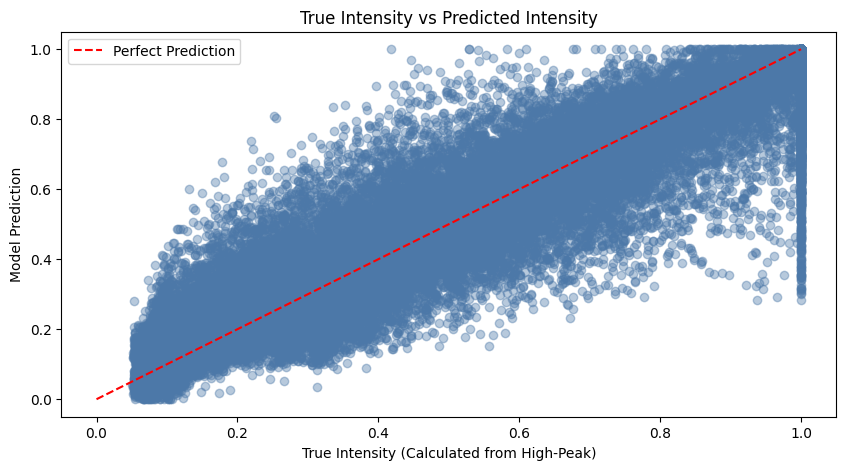

In [ ]:
# Draws Scatter Plot to check the distribution of predicted vs true intensities
plt.figure(figsize=(10, 5))
plt.scatter(y_test_i, predictions, alpha=0.4, color='#4C78A8')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
plt.title('True Intensity vs Predicted Intensity')
plt.xlabel('True Intensity (Calculated from High-Peak)')
plt.ylabel('Model Prediction')
plt.legend()
plt.show()

### Final Export to Arduino (Gesture + Intensity)
We now export both models. The C++ code will calculate both the discrete gesture index and the continuous intensity value

In [11]:
def export_dual_models_to_cpp(g_model, i_model, filename='dual_model.h'):
    with open(filename, 'w') as f:
        f.write('#ifndef DUAL_MODEL_H\n#define DUAL_MODEL_H\n\n#include <Arduino.h>\n\n')

        # Export weights for both models (Classifier and Regressor)
        for i, coef in enumerate(g_model.coefs_):
            f.write(f'const float GW{i}[{coef.shape[0]}][{coef.shape[1]}] PROGMEM = {{ ')
            f.write(', '.join(['{' + ', '.join(map(str, row)) + '}' for row in coef]) + ' };\n')
        for i, intercept in enumerate(g_model.intercepts_):
            f.write(f'const float Gb{i}[{intercept.shape[0]}] PROGMEM = {{ ' + ', '.join(map(str, intercept)) + ' };\n')

        for i, coef in enumerate(i_model.coefs_):
            f.write(f'const float IW{i}[{coef.shape[0]}][{coef.shape[1]}] PROGMEM = {{ ')
            f.write(', '.join(['{' + ', '.join(map(str, row)) + '}' for row in coef]) + ' };\n')
        for i, intercept in enumerate(i_model.intercepts_):
            f.write(f'const float Ib{i}[{intercept.shape[0]}] PROGMEM = {{ ' + ', '.join(map(str, intercept)) + ' };\n')

        f.write("""
int predict_gesture(float* input) {
    float h1[64]; for(int j=0; j<64; j++) { float s=pgm_read_float(&Gb0[j]); for(int i=0; i<15; i++) s+=input[i]*pgm_read_float(&GW0[i][j]); h1[j]=(s>0)?s:0; }
    float h2[32]; for(int j=0; j<32; j++) { float s=pgm_read_float(&Gb1[j]); for(int i=0; i<64; i++) s+=h1[i]*pgm_read_float(&GW1[i][j]); h2[j]=(s>0)?s:0; }
    int bc=0; float mv=-1e10; for(int j=0; j<5; j++) { float s=pgm_read_float(&Gb2[j]); for(int i=0; i<32; i++) s+=h2[i]*pgm_read_float(&GW2[i][j]); if(s>mv){mv=s; bc=j;} }
    return bc;
}

float predict_intensity(float* input) {
    float h1[64]; for(int j=0; j<64; j++) { float s=pgm_read_float(&Ib0[j]); for(int i=0; i<15; i++) s+=input[i]*pgm_read_float(&IW0[i][j]); h1[j]=(s>0)?s:0; }
    float h2[32]; for(int j=0; j<32; j++) { float s=pgm_read_float(&Ib1[j]); for(int i=0; i<64; i++) s+=h1[i]*pgm_read_float(&IW1[i][j]); h2[j]=(s>0)?s:0; }
    float s=pgm_read_float(&Ib2[0]); for(int i=0; i<32; i++) s+=h2[i]*pgm_read_float(&IW2[i][0]);

    // CRITICAL: Safety Clamping for Arduino to ensure value is strictly between 0.0 and 1.0
    if (s < 0.0f) return 0.0f;
    if (s > 1.0f) return 1.0f;
    return s;
}
""")
        f.write('\n#endif')

export_dual_models_to_cpp(model, intensity_model)
print('Dual model with range safety exported to dual_model.h')


Dual model with range safety exported to dual_model.h


## Generating Test Samples For Arduino Code
We need to generate a test sample that simulates the realtime EMG acquisition of our hardware

In [12]:
import h5py
import scipy.io as sio
import numpy as np
import os
import shutil

local_data = "/content/temp_emg.mat"
local_labels = "/content/temp_labels.mat"

try:
    # Load Data and Labels
    if not os.path.exists(local_data): shutil.copy2(emg_s_path, local_data)
    if not os.path.exists(local_labels): shutil.copy2(labels_path, local_labels)

    with h5py.File(local_data, 'r') as f:
        data_ptr = f['final_matrix']

        mat_lab = sio.loadmat(local_labels)
        lab_key = [k for k in mat_lab.keys() if not k.startswith('__')][0]
        all_labels = mat_lab[lab_key].flatten()

        # Targeted Selection
        fist_indices = np.where(all_labels == 0)[0]
        rest_indices = np.where(all_labels == 4)[0]

        if len(fist_indices) < 150 or len(rest_indices) < 50:
            raise ValueError("Not enough samples in dataset.")

        # Select indices
        selected_fist = np.random.choice(fist_indices, 150, replace=False)
        selected_rest = np.random.choice(rest_indices, 50, replace=False)

        # Indices must be sorted to index the dataset
        unsorted_indices = np.concatenate([selected_fist, selected_rest])
        sort_idx = np.argsort(unsorted_indices)
        final_indices = unsorted_indices[sort_idx]

        # Extract data using sorted indices
        selected_windows = np.array(data_ptr[:, :, final_indices])
        selected_labels = all_labels[final_indices]

    # Write Header
    with open("test_emg_data.h", "w") as f_out:
        f_out.write("// Generated Test Data: Mixed Fist and Rest samples (Sorted by original index)\n")
        f_out.write("const int NUM_TEST_WINDOWS = 200;\n")
        f_out.write("const int test_labels[200] = {" + ", ".join(map(str, selected_labels.astype(int))) + "};\n")
        f_out.write("const float test_emg_data[200][3][375] = {\n")
        for w in range(200):
            f_out.write("  {")
            for c in range(3):
                f_out.write("{" + ", ".join([f"{v:.6f}" for v in selected_windows[:, c, w]]) + "}")
                if c < 2: f_out.write(", ")
            f_out.write("}" + (",\n" if w < 199 else "\n"))
        f_out.write("};\n")

    print("Successfully generated test_emg_data.h with sorted indices to satisfy HDF5 requirements.")

except Exception as e:
    print(f"Failed to generate specific test samples: {str(e)}")

Failed to generate specific test samples: [Errno 2] No such file or directory: '/content/temp_emg.mat'
